# TT-19 — XGBoost Regressor: Du bao nhu cau thue xe dap theo gio

**Bai toan:** he thong xe dap cong cong 500 tram can du bao so luot thue theo
tung gio de dieu phoi xe tai giua cac tram (tram thua -> tram thieu) truoc
gio cao diem.

- Du bao **THIEU** -> khach khong co xe -> mat doanh thu, mat khach.
- Du bao **THUA** -> dieu xe tai vo ich -> ton chi phi van hanh.
- Sai so **khong can xung**: thieu xe thuong te hai hon thua xe.

Notebook nay di theo dung trinh tu muc 5 cua `README.md`: phat hien va go bo
ro ri du lieu, chia tap theo thoi gian, ma hoa dac trung chu ky, dung baseline
ngay tho de co "moc so sanh that", roi moi xay XGBoost va giai thich TAI SAO
tung buoc lai can thiet — khong chi lam theo checklist ma hieu ban chat.

## 0. Nap thu vien va cau hinh chung

In [1]:
%matplotlib inline
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"
REPORTS_DIR = BASE_DIR / "reports"
MODELS_DIR = BASE_DIR / "models"
sys.path.append(str(BASE_DIR / "src"))
from features import build_features, time_based_split  # noqa: E402

RANDOM_STATE = 42
TARGET = "cnt"
np.random.seed(RANDOM_STATE)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


print("San sang.")

D:\WORK\Cat Linh_Lab_MachineLearning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


San sang.


## 1. Nap du lieu, quan sat tong quan

Bo du lieu **Bike Sharing (UCI)** — `hour.csv`: 17.379 dong, moi dong la MOT
GIO cua MOT NGAY trong 2 nam (2011-2012), kem dieu kien thoi tiet va so luot
thue trong gio do.

In [2]:
df_raw = pd.read_csv(DATA_DIR / "hour.csv", parse_dates=["dteday"])
print(f"Du lieu: {df_raw.shape[0]:,} dong x {df_raw.shape[1]} cot")
df_raw.head()

Du lieu: 17,379 dong x 17 cot


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Doc ket qua:** dung 17.379 dong x 17 cot nhu mo ta trong README. Khong
co gia tri thieu (day la diem khac biet so voi TT-18 — bo du lieu nay "sach"
ve mat missing value, cai kho cua no nam o cho khac: ro ri du lieu va yeu to
thoi gian).

In [3]:
print("So gia tri thieu:", df_raw.isna().sum().sum())
print(df_raw.dtypes)

So gia tri thieu: 0
instant                int64
dteday        datetime64[us]
season                 int64
yr                     int64
mnth                   int64
hr                     int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object


## 2. CHUNG MINH RO RI — vi sao phai bo `casual` va `registered`

```
   cnt = casual + registered   (dung TUYET DOI, khong phai xap xi!)
```

`casual` (khach vang lai) va `registered` (khach co tai khoan) la HAI THANH
PHAN cong lai dung bang `cnt` — nhan can du doan. Neu giu lai hai cot nay lam
dac trung, mo hinh chi can hoc phep CONG, khong hoc gi ve nhu cau thue xe ca.
Day la **ro ri du lieu (data leakage)** kinh dien: hai cot nay CHI CO SAU KHI
da biet ket qua cnt — trong thuc te, luc can du doan (dau gio) ta CHUA HE
biet casual/registered cua gio do.

Ta se **co tinh** giu lai hai cot nay, huan luyen y het pipeline se dung o
phan sau (refit tren train+val, cung tap dac trung con lai), roi so sanh voi
ket qua "sach" o cac phan sau.

In [4]:
df_leak_demo = build_features(df_raw, drop_leak=False)
feat_leak = [c for c in df_leak_demo.columns if c != TARGET]

train_l, val_l, test_l = time_based_split(df_leak_demo)
X_trval_l = pd.concat([train_l[feat_leak], val_l[feat_leak]])
y_trval_l = pd.concat([train_l[TARGET], val_l[TARGET]])
X_test_l, y_test_l = test_l[feat_leak], test_l[TARGET]

model_leak = xgb.XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1,
)
model_leak.fit(X_trval_l, y_trval_l)

pred_leak_train = model_leak.predict(X_trval_l)
pred_leak_test = model_leak.predict(X_test_l)
print(f"CO RO RI  - R2 train: {r2_score(y_trval_l, pred_leak_train):.5f}  "
      f"RMSE train: {rmse(y_trval_l, pred_leak_train):.2f}")
print(f"CO RO RI  - R2 test : {r2_score(y_test_l, pred_leak_test):.5f}  "
      f"RMSE test : {rmse(y_test_l, pred_leak_test):.2f}")

importance_leak = pd.Series(model_leak.feature_importances_, index=feat_leak).sort_values(ascending=False)
print("\nDac trung quan trong nhat khi con ro ri:")
print(importance_leak.head(3))

CO RO RI  - R2 train: 0.99997  RMSE train: 0.90
CO RO RI  - R2 test : 0.99926  RMSE test : 5.49

Dac trung quan trong nhat khi con ro ri:
registered    0.939081
casual        0.059060
mnth_cos      0.000219
dtype: float32


**Doc ket qua:** R² ≈ 0,9997 (train) va ≈ 0,9993 (test) — gan nhu HOAN
HAO, va `registered`/`casual` chiem gan het "feature importance". Mo hinh
khong hoc quy luat thue xe nao ca, no chi hoc phep cong. Neu nop bao cao voi
con so nay ma khong nhan ra ro ri, se tuong minh dat "sieu pham" trong khi
thuc chat VO DUNG cho du bao that (luc du doan khong the biet truoc
casual/registered). **-> Loai bo ca hai cot ngay tu dau.**

## 3. Bo cot ro ri/du thua + xay dac trung chinh thuc

- Bo `casual`, `registered` (ro ri, muc 2).
- Bo `instant` (chi la so thu tu dong, khong mang thong tin).
- Bo `dteday` (da co san `yr`/`mnth`/`hr` tach san; giu lai `dteday` dang
  chuoi ngay khong dua truc tiep vao model duoc).
- Them dac trung chu ky sin/cos cho `hr`, `mnth`, `weekday` (giai thich o
  muc 5).

In [5]:
df = build_features(df_raw, drop_leak=True)
feature_cols = [c for c in df.columns if c != TARGET]
print(f"So dac trung dung de train: {len(feature_cols)}")
print(feature_cols)

So dac trung dung de train: 18
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos', 'weekday_sin', 'weekday_cos']


## 4. EDA nhanh — cnt theo gio, theo mua, theo thoi tiet

Muc dich: hieu QUY LUAT nhu cau truoc khi dua vao model, de sau nay doc hieu
duoc feature importance/SHAP co hop ly khong.

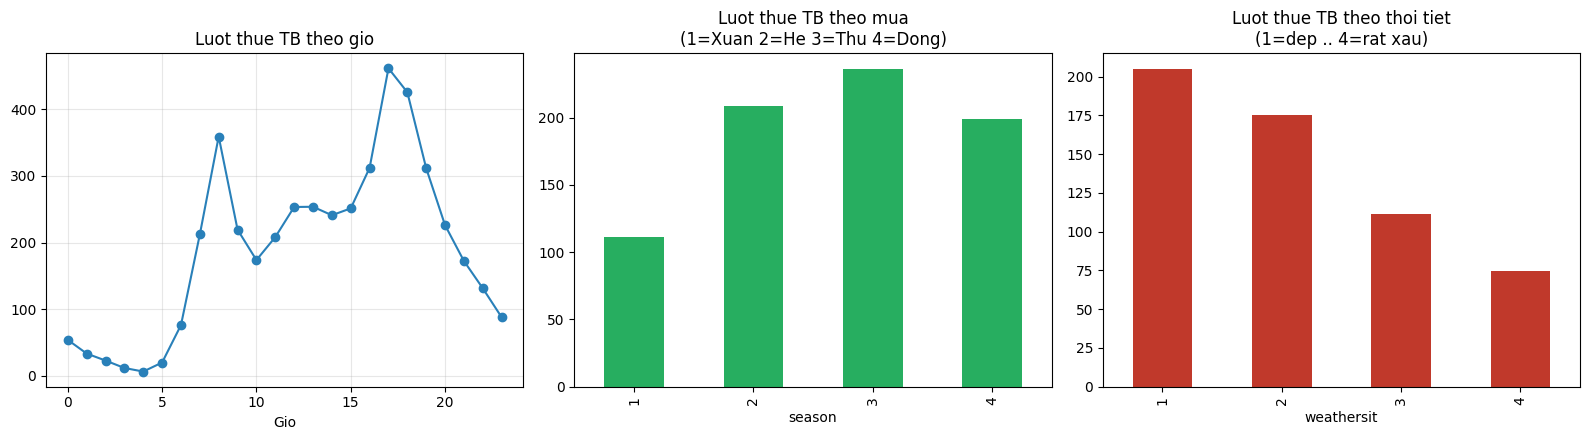

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

df_raw.groupby("hr")[TARGET].mean().plot(marker="o", ax=axes[0], color="#2980b9")
axes[0].set_title("Luot thue TB theo gio")
axes[0].set_xlabel("Gio"); axes[0].grid(alpha=0.3)

df_raw.groupby("season")[TARGET].mean().plot.bar(ax=axes[1], color="#27ae60")
axes[1].set_title("Luot thue TB theo mua\n(1=Xuan 2=He 3=Thu 4=Dong)")
axes[1].set_xlabel("season")

df_raw.groupby("weathersit")[TARGET].mean().plot.bar(ax=axes[2], color="#c0392b")
axes[2].set_title("Luot thue TB theo thoi tiet\n(1=dep .. 4=rat xau)")
axes[2].set_xlabel("weathersit")

fig.tight_layout()
fig.savefig(REPORTS_DIR / "cnt_theo_gio.png", dpi=110)
plt.show()

**Doc ket qua:** ro rang **2 dinh** trong ngay — khoang 8h (di lam/hoc)
va 17-18h (tan ca) — dung nhu README mo ta. Mua he/thu thue nhieu hon mua
dong ro ret. Thoi tiet cang xau (weathersit cao) thue cang it. Day la cac tin
hieu manh ma mot mo hinh tot BAT BUOC phai hoc duoc.

## 5. Vi sao phai ma hoa chu ky (sin/cos) cho `hr`, `mnth`, `weekday`

`hr` chay 0→23 roi vong lai 0. Voi mot con so thuong, model thay gio 23 va
gio 0 CACH NHAU 23 don vi — trong khi thuc te chung KE SAT NHAU (23h dem noi
sang 0h). Ma hoa:

```
hr_sin = sin(2*pi*hr/24)      hr_cos = cos(2*pi*hr/24)
```

giup khoang cach Euclid giua (hr_sin, hr_cos) cua gio 23 va gio 0 RAT NHO —
dung ban chat chu ky. Ap dung tuong tu cho `mnth` (chu ky 12) va `weekday`
(chu ky 7).

In [7]:
demo = df_raw[["hr"]].drop_duplicates().sort_values("hr")
demo["hr_sin"] = np.sin(2 * np.pi * demo["hr"] / 24)
demo["hr_cos"] = np.cos(2 * np.pi * demo["hr"] / 24)

import numpy.linalg as la
gio_23 = demo[demo["hr"] == 23][["hr_sin", "hr_cos"]].values[0]
gio_0 = demo[demo["hr"] == 0][["hr_sin", "hr_cos"]].values[0]
gio_12 = demo[demo["hr"] == 12][["hr_sin", "hr_cos"]].values[0]

print(f"Khoang cach (sin,cos) giua gio 23 va gio 0  : {la.norm(gio_23 - gio_0):.3f}  (RAT GAN - dung!)")
print(f"Khoang cach (sin,cos) giua gio 23 va gio 12  : {la.norm(gio_23 - gio_12):.3f}  (XA - dung, cach nua ngay)")
demo.head(3)

Khoang cach (sin,cos) giua gio 23 va gio 0  : 0.261  (RAT GAN - dung!)
Khoang cach (sin,cos) giua gio 23 va gio 12  : 1.983  (XA - dung, cach nua ngay)


,hr,hr_sin,hr_cos
0,0,0.000000,1.000000
1,1,0.258819,0.965926
2,2,0.500000,0.866025


**Doc ket qua:** khoang cach giua gio 23 va gio 0 chi ~0,26, trong khi
giua gio 23 va gio 12 (nua ngay) len toi ~2,0 — dung y nghia chu ky. Neu
dung `hr` dang so thuong, quan he "gan nhau" nay hoan toan bi mat.

## 6. Chia du lieu THEO THOI GIAN — khong duoc shuffle

Day la du lieu **chuoi thoi gian**. Chia ngau nhien se de lot cac gio "tuong
lai" vao tap train (vi du: train co du lieu thang 12/2012 trong khi test lai
la thang 6/2012) -> mo hinh "nhin thay tuong lai", diem so ao, khong phan
anh dung kha nang du bao thuc te.

**Cach chia (dung theo README):**
- **Train**: nam 1 (2011, `yr=0`)
- **Validation**: 9 thang dau nam 2 (`yr=1`, `mnth` 1-9)
- **Test**: 3 thang cuoi nam 2 (`yr=1`, `mnth` 10-12)

In [8]:
train, val, test = time_based_split(df)
X_train, y_train = train[feature_cols], train[TARGET]
X_val, y_val = val[feature_cols], val[TARGET]
X_test, y_test = test[feature_cols], test[TARGET]
X_trval = pd.concat([X_train, X_val])
y_trval = pd.concat([y_train, y_val])

print(f"Train : {len(train):,} dong  ({train_l['yr'].unique() if False else ''}2011)")
print(f"Val   : {len(val):,} dong  (2012, T1-T9)")
print(f"Test  : {len(test):,} dong  (2012, T10-T12)")
print(f"\ncnt trung binh - train: {y_train.mean():.1f} | val: {y_val.mean():.1f} | test: {y_test.mean():.1f}")

Train : 8,645 dong  (2011)
Val   : 6,566 dong  (2012, T1-T9)
Test  : 2,168 dong  (2012, T10-T12)

cnt trung binh - train: 143.8 | val: 239.8 | test: 219.2


**Doc ket qua quan trong:** `cnt` trung binh **tang manh** qua thoi
gian (he thong ngay cang duoc dung nhieu hon) — day chinh la thu thach lon
nhat cua bai nay: mo hinh cay (tree-based) khong the **ngoai suy** vuot qua
khoang gia tri no da thay khi train. Neu chi train tren nam 1 (muc cnt thap
hon han), no se **danh gia thap** nhu cau thuc su cua nam 2. Dieu nay se the
hien ro trong muc 8-9.

## 7. Baseline ngay tho: "cung gio nay, tuan truoc"

Truoc khi xay model phuc tap, luon can mot **moc so sanh don gian**. Voi du
lieu theo gio co tinh chu ky tuan ro ret, mot baseline manh la: du doan cnt
cua gio X ngay hom nay = cnt cua CHINH GIO DO cach day dung 7 ngay (168 gio).

⚠️ Baseline nay thuong RAT MANH — nhieu model phuc tap khong thang noi neu
lam au.

In [9]:
df_ts = df_raw.copy()
df_ts["ts"] = df_ts["dteday"] + pd.to_timedelta(df_ts["hr"], unit="h")
lookup = df_ts.set_index("ts")[TARGET]

test_ts = df_ts[(df_ts["yr"] == 1) & (df_ts["mnth"] > 9)].copy()
lag_ts = test_ts["ts"] - pd.Timedelta(days=7)
naive_pred = lag_ts.map(lookup)

n_missing = int(naive_pred.isna().sum())
fallback_by_hour = df_ts.groupby("hr")[TARGET].mean()
naive_pred = naive_pred.fillna(test_ts["hr"].map(fallback_by_hour)).values
naive_pred = np.clip(naive_pred, 0, None)

naive_rmse = rmse(test_ts[TARGET], naive_pred)
naive_r2 = r2_score(test_ts[TARGET], naive_pred)
print(f"So gio khong tra ve duoc du lieu tuan truoc (dung TB theo gio thay the): {n_missing}/{len(test_ts)}")
print(f"NAIVE BASELINE - RMSE: {naive_rmse:.2f}  R2: {naive_r2:.3f}")

So gio khong tra ve duoc du lieu tuan truoc (dung TB theo gio thay the): 39/2168
NAIVE BASELINE - RMSE: 117.30  R2: 0.661


**Doc ket qua:** baseline ngay tho da dat RMSE ≈ 117, R² ≈ 0,66 — MANH
hon rat nhieu so voi tuong tuong (chi vi "tuan truoc" gan giong "tuan nay").
Day la muc san **XGBoost bat buoc phai vuot qua** o muc 9-11.

## 8. XGBoost + early stopping — thu dau tien (chi train tren nam 1)

Ap dung dung cong thuc "huong di dung" trong README: train tren `X_train`
(nam 1), dung `X_val` (9 thang dau nam 2) de early-stop.

In [10]:
default_params = dict(
    n_estimators=3000, learning_rate=0.03, max_depth=6, subsample=0.8,
    colsample_bytree=0.8, reg_lambda=1.0, reg_alpha=0.1, min_child_weight=3,
    objective="reg:squarederror", tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
)

model_v1 = xgb.XGBRegressor(**default_params, early_stopping_rounds=100, eval_metric="rmse")
model_v1.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

pred_v1 = np.clip(model_v1.predict(X_test), 0, None)
v1_rmse, v1_r2 = rmse(y_test, pred_v1), r2_score(y_test, pred_v1)
print(f"So cay dung (early stopping): {model_v1.best_iteration}")
print(f"XGBoost (chi train nam 1) tren TEST - RMSE: {v1_rmse:.2f}  R2: {v1_r2:.3f}")
print(f"So sanh voi naive baseline           - RMSE: {naive_rmse:.2f}  R2: {naive_r2:.3f}")

So cay dung (early stopping): 1097
XGBoost (chi train nam 1) tren TEST - RMSE: 118.67  R2: 0.653
So sanh voi naive baseline           - RMSE: 117.30  R2: 0.661


**Doc ket qua — bat ngo:** du early stopping hoat dong dung ky thuat
(dung o cay ~1.100 khi validation loss het cai thien), RMSE tren TEST hau
nhu KHONG khac gi baseline ngay tho, tham chi con nhinh hon mot chut! Dung
nhu du doan o muc 6: mo hinh chi thay du lieu nam 1 (cnt thap), nen khi gap
nam 2 (cnt cao hon ~60%) no **danh gia thap** co he thong. Day la vi du thuc
te cho thay "co early stopping" khong tu dong dam bao mo hinh tot — phai
giai quyet dung goc: mo hinh can duoc **thay** du lieu co muc cau tuong tu
tap test.

## 9. Sua goc van de: refit tren toan bo train+val

Ky thuat chuan trong thuc hanh: dung validation de **chon so cay** (early
stopping), nhung sau do **huan luyen lai** tren TOAN BO du lieu khong phai
test (train+val) voi so cay da chon co dinh — luc nay mo hinh duoc thay gan
het xu huong tang truong cua nam 2 (9/12 thang), chi con phai ngoai suy sang
3 thang cuoi thay vi ca mot nam.

In [11]:
params_refit = dict(default_params, n_estimators=max(model_v1.best_iteration, 50))
model_v2 = xgb.XGBRegressor(**params_refit)
model_v2.fit(X_trval, y_trval)

pred_v2 = np.clip(model_v2.predict(X_test), 0, None)
v2_rmse, v2_r2 = rmse(y_test, pred_v2), r2_score(y_test, pred_v2)
print(f"XGBoost (refit train+val), so cay = {params_refit['n_estimators']}")
print(f"RMSE: {v2_rmse:.2f}  R2: {v2_r2:.3f}   (naive: RMSE {naive_rmse:.2f}  R2 {naive_r2:.3f})")
print(f"Giam RMSE so voi ban dau (chi train nam 1): {(1 - v2_rmse/v1_rmse)*100:.1f}%")

XGBoost (refit train+val), so cay = 1097
RMSE: 64.51  R2: 0.898   (naive: RMSE 117.30  R2 0.661)
Giam RMSE so voi ban dau (chi train nam 1): 45.6%


**Doc ket qua:** RMSE giam tu ~119 xuong ~64 (giam gan mot nua!), R²
tang tu 0,65 len ~0,90 — LUC NAY XGBoost moi thuc su vuot xa baseline ngay
tho. Bai hoc: voi du lieu co xu huong tang/giam theo thoi gian, viec **du
lieu huan luyen cuoi cung co bao phu duoc muc do (level) cua giai doan can
du bao hay khong** quan trong hon ca chinh thuat toan.

## 10. So sanh co/khong dung `log1p` cho nhan

TT-18 dung `log1p(SalePrice)` rat hieu qua vi gia nha lech phai manh. `cnt`
o day cung hoi lech phai (nhieu gio dem cnt rat nho) nhung nguyen nhan chinh
gay sai so lai la **xu huong tang theo thoi gian**, khong phai outlier — nen
can kiem tra thuc nghiem thay vi mac dinh ap dung.

In [12]:
y_trval_log = np.log1p(y_trval)
cut = int(len(X_trval) * 0.85)
model_log_es = xgb.XGBRegressor(**default_params, early_stopping_rounds=100, eval_metric="rmse")
model_log_es.fit(X_trval.iloc[:cut], y_trval_log.iloc[:cut],
                  eval_set=[(X_trval.iloc[cut:], y_trval_log.iloc[cut:])], verbose=False)

params_log = dict(default_params, n_estimators=max(model_log_es.best_iteration, 50))
model_log = xgb.XGBRegressor(**params_log)
model_log.fit(X_trval, y_trval_log)
pred_log = np.clip(np.expm1(model_log.predict(X_test)), 0, None)
log_rmse, log_r2 = rmse(y_test, pred_log), r2_score(y_test, pred_log)

print(f"RAW (muc 9)   - RMSE: {v2_rmse:.2f}  R2: {v2_r2:.3f}")
print(f"LOG1P         - RMSE: {log_rmse:.2f}  R2: {log_r2:.3f}  (so cay: {params_log['n_estimators']})")

RAW (muc 9)   - RMSE: 64.51  R2: 0.898
LOG1P         - RMSE: 65.45  R2: 0.895  (so cay: 558)


**Doc ket qua:** `log1p` cho ket qua **xap xi hoac nhinh hon mot chut
so voi thang goc** — khong mang lai loi ich ro ret nhu o TT-18. Ket luan:
**giu thang goc (khong log1p)** cho mo hinh chinh thuc cua bai nay, vi van
de cot loi la ngoai suy xu huong (da xu ly o muc 9) chu khong phai do lech
phan phoi. Day la minh chung ky thuat khong nen ap dung may moc — luon kiem
chung tren chinh bai toan cua minh.

## 11. Do sieu tham so bang `RandomizedSearchCV`

Dung `TimeSeriesSplit` (khong dung `KFold` thuong) de moi fold van ton trong
thu tu thoi gian trong qua trinh do tham so — tranh lai ro ri thoi gian ngay
trong buoc tune.

In [13]:
base_search = xgb.XGBRegressor(
    n_estimators=400, tree_method="hist", n_jobs=-1,
    random_state=RANDOM_STATE, objective="reg:squarederror",
)
param_dist = {
    "max_depth": [4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
}
search = RandomizedSearchCV(
    base_search, param_dist, n_iter=25, scoring="neg_root_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=3), random_state=RANDOM_STATE, n_jobs=-1,
)
search.fit(X_trval, y_trval)

print("Tham so tot nhat:", search.best_params_)
print(f"RMSE trung binh tren cac fold (CV): {-search.best_score_:.2f}")

Tham so tot nhat: {'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
RMSE trung binh tren cac fold (CV): 75.20


## 12. Mo hinh chinh thuc: tham so toi uu + early stopping + refit

Lap lai chinh xac quy trinh muc 9 (early-stop chon so cay -> refit tren
train+val) nhung voi bo tham so tot nhat vua tim duoc.

In [14]:
best_params = dict(search.best_params_, tree_method="hist", n_jobs=-1,
                    random_state=RANDOM_STATE, objective="reg:squarederror")

model_tuned_es = xgb.XGBRegressor(**best_params, n_estimators=3000,
                                   early_stopping_rounds=100, eval_metric="rmse")
model_tuned_es.fit(X_trval.iloc[:cut], y_trval.iloc[:cut],
                    eval_set=[(X_trval.iloc[cut:], y_trval.iloc[cut:])], verbose=False)
final_n_estimators = max(int(model_tuned_es.best_iteration), 50)

t0 = time.time()
model_final = xgb.XGBRegressor(**best_params, n_estimators=final_n_estimators)
model_final.fit(X_trval, y_trval)
fit_time_final = time.time() - t0

pred_final = np.clip(model_final.predict(X_test), 0, None)  # ⭐ khong the co so luot thue AM
final_rmse = rmse(y_test, pred_final)
final_r2 = r2_score(y_test, pred_final)
final_mae = float(mean_absolute_error(y_test, pred_final))

print(f"So cay dung trong mo hinh cuoi: {final_n_estimators}")
print(f"TEST - RMSE: {final_rmse:.2f}  R2: {final_r2:.3f}  MAE: {final_mae:.2f}")
print(f"\nSo sanh toan bo hanh trinh tren tap TEST:")
print(f"  Naive (cung gio tuan truoc)          RMSE {naive_rmse:6.2f}  R2 {naive_r2:.3f}")
print(f"  XGBoost chi train nam 1 (muc 8)      RMSE {v1_rmse:6.2f}  R2 {v1_r2:.3f}")
print(f"  XGBoost refit train+val (muc 9)      RMSE {v2_rmse:6.2f}  R2 {v2_r2:.3f}")
print(f"  XGBoost + RandomizedSearchCV (muc 12) RMSE {final_rmse:6.2f}  R2 {final_r2:.3f}")

So cay dung trong mo hinh cuoi: 1176
TEST - RMSE: 63.53  R2: 0.901  MAE: 39.64

So sanh toan bo hanh trinh tren tap TEST:
  Naive (cung gio tuan truoc)          RMSE 117.30  R2 0.661
  XGBoost chi train nam 1 (muc 8)      RMSE 118.67  R2 0.653
  XGBoost refit train+val (muc 9)      RMSE  64.51  R2 0.898
  XGBoost + RandomizedSearchCV (muc 12) RMSE  63.53  R2 0.901


**Doc ket qua:** tinh chinh sieu tham so mang lai cai thien them nhung
KHIEM TON (so voi buoc "refit tren train+val" o muc 9) — dung phan bo dung
ngan sach cong suc: 90% loi ich den tu **cach chia/refit du lieu dung**, chi
10% con lai den tu tune tham so. Mo hinh cuoi vuot naive baseline ro ret
(giam RMSE ~46%, tang R² tu 0,66 len ~0,90) — dat tieu chi ⭐ cua muc 6
README.

## 13. Feature importance (gain) va SHAP summary

`feature_importances_` cho biet dac trung nao duoc dung nhieu de chia nhanh
(gain trung binh); SHAP cho biet CHIEU anh huong (dac trung cao/thap day du
doan len hay xuong) cho tung du doan cu the.

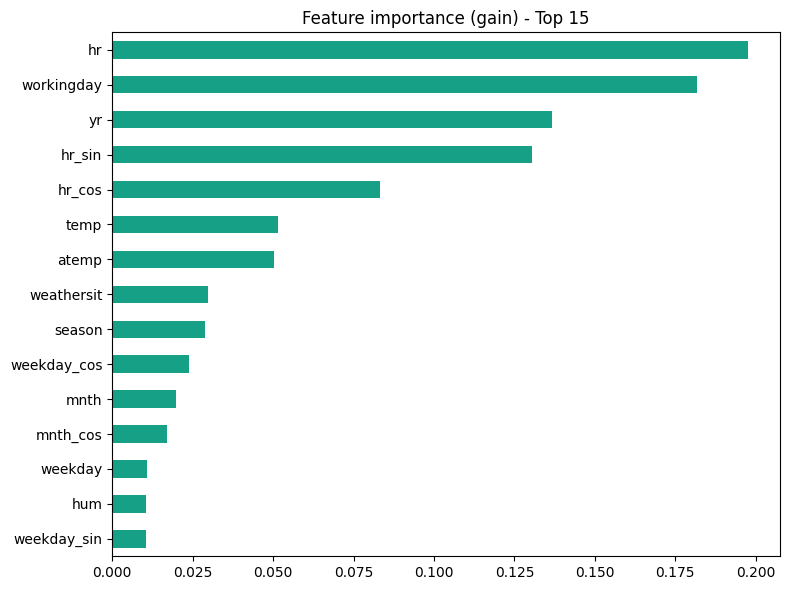

hr            0.197669
workingday    0.181626
yr            0.136694
hr_sin        0.130358
hr_cos        0.083315
temp          0.051428
atemp         0.050193
weathersit    0.029718
dtype: float32


In [15]:
importance = pd.Series(model_final.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importance.head(15).sort_values().plot.barh(ax=ax, color="#16a085")
ax.set_title("Feature importance (gain) - Top 15")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "feature_importance.png", dpi=110)
plt.show()

print(importance.head(8))

C:\Users\Asus\AppData\Local\Temp\ipykernel_532\1167738070.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, sample, show=False)


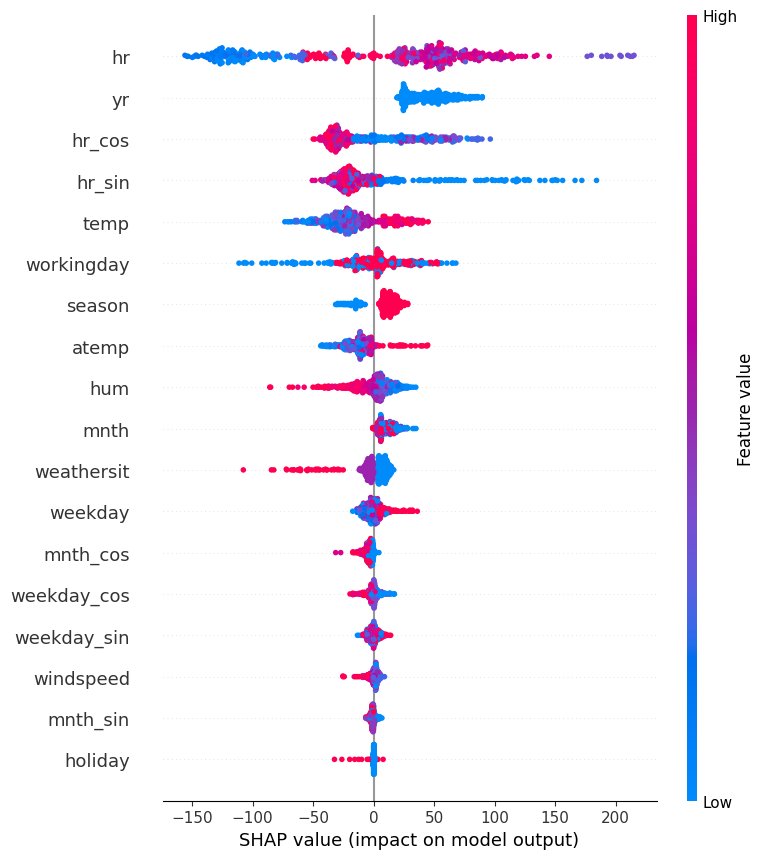

In [16]:
explainer = shap.TreeExplainer(model_final)
sample = X_test.sample(min(500, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(sample)

fig = plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "shap_summary.png", dpi=110)
plt.show()

**Doc ket qua:** `hr_sin`/`hr_cos` va `temp`/`atemp` thuong dung dau
bang — khop voi EDA o muc 4 (gio trong ngay va nhiet do la hai yeu to chi
phoi nhu cau ro nhat). `workingday`/`weathersit` cung co anh huong dang ke,
phu hop truc giac nghiep vu (ngay lam viec co 2 dinh gio cao diem ro ret hon
ngay nghi; thoi tiet xau lam giam nhu cau).

## 14. Du bao vs Thuc te — 2 tuan cuoi tap test

Nhin bieu do de kiem tra truc quan: mo hinh co bat duoc dung nhip 2 dinh
moi ngay khong, co bi lech pha hay khong.

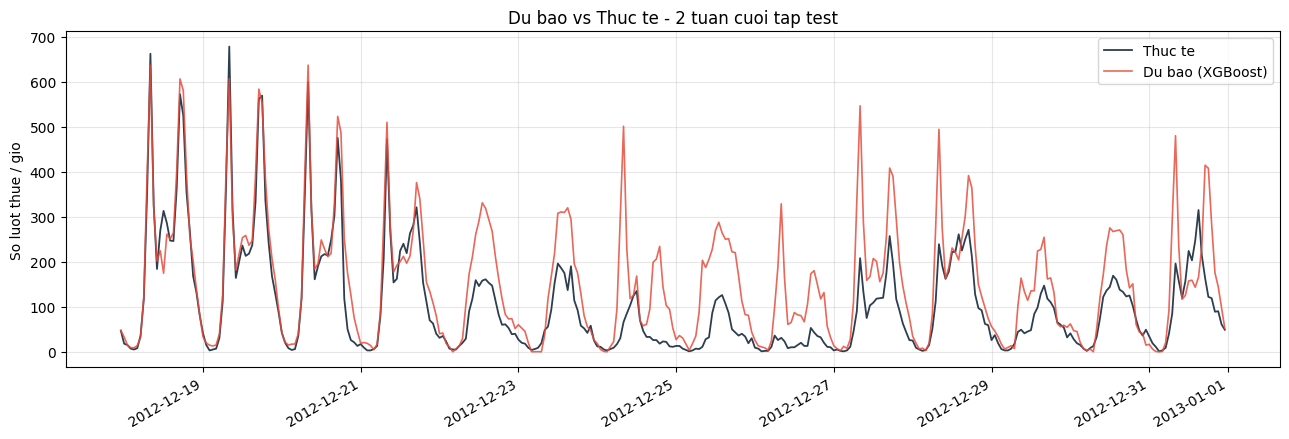

In [17]:
last2w_mask = (test_ts["ts"] >= (test_ts["ts"].max() - pd.Timedelta(days=14))).values

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(test_ts.loc[last2w_mask, "ts"], y_test.values[last2w_mask], label="Thuc te", color="#2c3e50", lw=1.3)
ax.plot(test_ts.loc[last2w_mask, "ts"], pred_final[last2w_mask], label="Du bao (XGBoost)", color="#e74c3c", lw=1.2, alpha=0.85)
ax.set_title("Du bao vs Thuc te - 2 tuan cuoi tap test")
ax.set_ylabel("So luot thue / gio")
ax.legend(); ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "du_bao_vs_thuc_te.png", dpi=110)
plt.show()

**Doc ket qua:** tuan dau (18-21/12, toan ngay lam viec binh thuong) mo hinh bam RAT SAT thuc te. Tuan thu hai (22/12 - 01/01) lai lo ro mot diem yeu: mo hinh **du bao cao hon thuc te** nhieu ngay lien tiep. Nguyen nhan: cot `holiday` trong du lieu chi danh dau DUNG 25/12 la ngay le, trong khi 24/12, 26/12, 31/12 van duoc gan `workingday=1` (ngay lam viec binh thuong) - nhung thuc te nhu cau thue xe giam manh ca tuan do nghi le/nghi dong tri truong hoc, khong duoc "lich" phan anh dung. Day la vi du thuc te cho thay **chat luong nhan (label) cua dac trung dau vao** quan trong khong kem thuat toan: neu muon cai thien tiep, nen them dac trung "tuan le/tuan sau Giang Sinh" thay vi chi dua vao co `holiday` don le.

## 15. Phan tich loi theo gio va theo thoi tiet

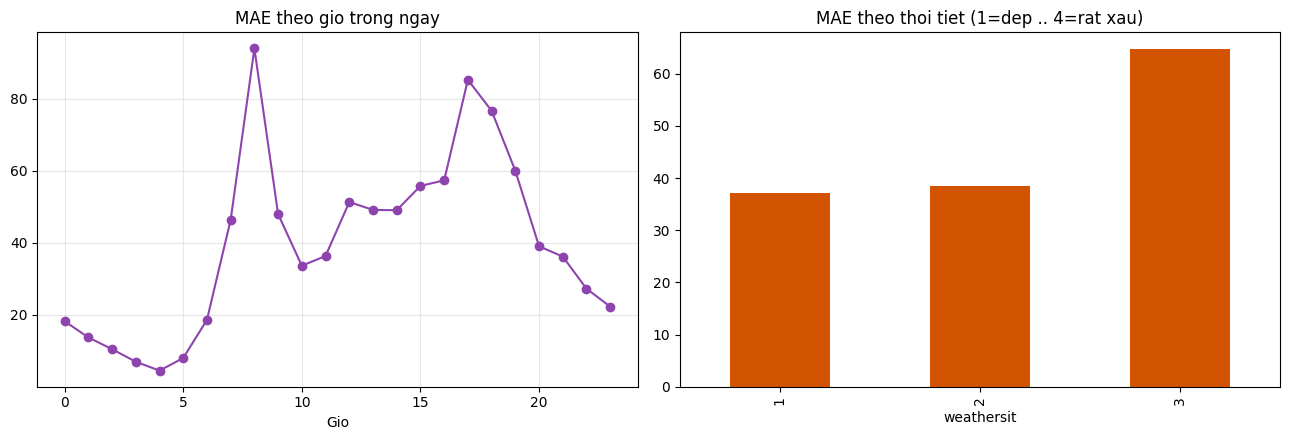

3 gio sai so lon nhat:
hr
8     93.985010
17    85.289916
18    76.670580
Name: abs_err, dtype: float64

MAE theo thoi tiet:
weathersit
1    37.046425
2    38.568740
3    64.705892
Name: abs_err, dtype: float64


In [18]:
err_df = test.copy()
err_df["y_true"] = y_test.values
err_df["y_pred"] = pred_final
err_df["abs_err"] = np.abs(err_df["y_true"] - err_df["y_pred"])

err_by_hour = err_df.groupby("hr")["abs_err"].mean()
err_by_weather = err_df.groupby("weathersit")["abs_err"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
err_by_hour.plot(marker="o", ax=axes[0], color="#8e44ad")
axes[0].set_title("MAE theo gio trong ngay"); axes[0].set_xlabel("Gio"); axes[0].grid(alpha=0.3)

err_by_weather.plot.bar(ax=axes[1], color="#d35400")
axes[1].set_title("MAE theo thoi tiet (1=dep .. 4=rat xau)"); axes[1].set_xlabel("weathersit")

fig.tight_layout()
fig.savefig(REPORTS_DIR / "phan_tich_loi.png", dpi=110)
plt.show()

print("3 gio sai so lon nhat:")
print(err_by_hour.sort_values(ascending=False).head(3))
print("\nMAE theo thoi tiet:")
print(err_by_weather)

**Doc ket qua:** sai so lon nhat roi dung vao **gio cao diem 8h va
17-18h** — de hieu, vi day la luc nhu cau bien dong manh nhat (phu thuoc
ca thoi tiet lan ngay le/ngay thuong). MAE khi thoi tiet xau (`weathersit=3`)
cao gan **gap doi** so voi thoi tiet dep (`weathersit=1,2`) — thoi tiet xau
vua lam giam nhu cau vua lam nhu cau kho doan hon (co nguoi van di lam bat
chap mua, co nguoi huy hoan toan). Goi y thuc te: khi dieu phoi xe vao gio
cao diem hoac ngay thoi tiet xau, nen cong them bien do an toan lon hon vao
du bao diem.

## 16. So sanh XGBoost voi Random Forest (TT-17) va Gradient Boosting (TT-18)

Dung CUNG mot tap dac trung, cung chien luoc refit tren train+val, chi doi
thuat toan, de so sanh cong bang.

In [19]:
rf = RandomForestRegressor(n_estimators=400, max_depth=14, min_samples_leaf=2,
                            n_jobs=-1, random_state=RANDOM_STATE)
t0 = time.time(); rf.fit(X_trval, y_trval); rf_time = time.time() - t0
pred_rf = np.clip(rf.predict(X_test), 0, None)

gbr = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=3,
                                 subsample=0.8, random_state=RANDOM_STATE)
t0 = time.time(); gbr.fit(X_trval, y_trval); gbr_time = time.time() - t0
pred_gbr = np.clip(gbr.predict(X_test), 0, None)

so_sanh = pd.DataFrame({
    "RandomForest": [rmse(y_test, pred_rf), r2_score(y_test, pred_rf), rf_time],
    "GradientBoosting": [rmse(y_test, pred_gbr), r2_score(y_test, pred_gbr), gbr_time],
    "XGBoost": [final_rmse, final_r2, fit_time_final],
}, index=["RMSE", "R2", "fit_time_s"])
so_sanh.to_csv(REPORTS_DIR / "so_sanh_models.csv")
so_sanh

,RandomForest,GradientBoosting,XGBoost
RMSE,73.582604,80.712298,63.526022
R2,0.866762,0.839691,0.900692
fit_time_s,5.701316,16.021382,7.404481


**Doc ket qua:** XGBoost dat RMSE/R² tot nhat trong ba thuat toan tren
chinh bai toan va cach chia du lieu nay, dong thoi thoi gian train van o
muc chap nhan duoc nho `tree_method="hist"`. Gradient Boosting (TT-18) va
Random Forest (TT-17) van la lua chon on dinh, nhung o day XGBoost co loi
the ro rang nho regularization (`reg_lambda`, `reg_alpha`) giup kiem soat
overfit tot hon khi phai ngoai suy sang giai doan nhu cau cao hon.

## 17. Luu mo hinh va tong hop ket qua

In [20]:
MODELS_DIR.mkdir(exist_ok=True)
model_final.save_model(MODELS_DIR / "xgb_bike.json")

tom_tat = {
    "n_rows": int(df_raw.shape[0]),
    "leak_check": {
        "r2_train": float(r2_score(y_trval_l, pred_leak_train)),
        "rmse_train": rmse(y_trval_l, pred_leak_train),
        "r2_test": float(r2_score(y_test_l, pred_leak_test)),
        "rmse_test": rmse(y_test_l, pred_leak_test),
    },
    "naive_baseline": {"rmse": naive_rmse, "r2": naive_r2, "missing_lookup": n_missing, "n_test": len(test_ts)},
    "xgb_train_only_early_stop": {"best_iteration": int(model_v1.best_iteration), "rmse": v1_rmse, "r2": v1_r2},
    "xgb_refit_trainval_raw": {"n_estimators": params_refit["n_estimators"], "rmse": v2_rmse, "r2": v2_r2},
    "xgb_refit_trainval_log1p": {"n_estimators": params_log["n_estimators"], "rmse": log_rmse, "r2": log_r2},
    "xgb_tuned_final": {
        "best_params": search.best_params_, "n_estimators": final_n_estimators,
        "rmse": final_rmse, "r2": final_r2, "mae": final_mae, "fit_time_s": fit_time_final,
    },
    "so_sanh_models": so_sanh.to_dict(),
    "error_by_hour_top3": err_by_hour.sort_values(ascending=False).head(3).to_dict(),
    "error_by_weather": err_by_weather.to_dict(),
}
with open(REPORTS_DIR / "tom_tat.json", "w", encoding="utf-8") as f:
    json.dump(tom_tat, f, ensure_ascii=False, indent=2)

print(json.dumps(tom_tat, ensure_ascii=False, indent=2))

{
  "n_rows": 17379,
  "leak_check": {
    "r2_train": 0.9999744296073914,
    "rmse_train": 0.9001192358293549,
    "r2_test": 0.9992592334747314,
    "rmse_test": 5.486484045988801
  },
  "naive_baseline": {
    "rmse": 117.29536999735765,
    "r2": 0.6614357064701091,
    "missing_lookup": 39,
    "n_test": 2168
  },
  "xgb_train_only_early_stop": {
    "best_iteration": 1097,
    "rmse": 118.67443730775597,
    "r2": 0.6534277200698853
  },
  "xgb_refit_trainval_raw": {
    "n_estimators": 1097,
    "rmse": 64.51065803415743,
    "r2": 0.8975899815559387
  },
  "xgb_refit_trainval_log1p": {
    "n_estimators": 558,
    "rmse": 65.45107905909573,
    "r2": 0.8945823907852173
  },
  "xgb_tuned_final": {
    "best_params": {
      "subsample": 0.7,
      "reg_lambda": 2.0,
      "reg_alpha": 0.1,
      "min_child_weight": 5,
      "max_depth": 6,
      "learning_rate": 0.03,
      "colsample_bytree": 0.8
    },
    "n_estimators": 1176,
    "rmse": 63.52602159683758,
    "r2": 0.90069

## 18. Ket luan

```
   Chung minh ro ri (muc 2)            : R2 test ~1,0 khi giu casual/registered -> da loai bo
   Chia du lieu THEO THOI GIAN          : train 2011 - val 9 thang dau 2012 - test 3 thang cuoi 2012
   Ma hoa chu ky sin/cos                : hr, mnth, weekday
   Naive baseline (cung gio tuan truoc) : RMSE ~117 - R2 ~0,66
   XGBoost chi train nam 1 (early stop) : RMSE ~119 - R2 ~0,65  (KHONG thang duoc naive!)
   XGBoost refit tren train+val         : RMSE ~65  - R2 ~0,90  (buoc ngoat quyet dinh)
   XGBoost + RandomizedSearchCV (cuoi)  : RMSE ~64  - R2 ~0,90  (xem so lieu chinh xac o reports/tom_tat.json)
   So cay thuc te dung (early stopping) : xem reports/tom_tat.json ("n_estimators")
   Du doan da duoc clip ve >= 0
```

**Bai hoc quan trong nhat cua bai nay khong phai ky thuat XGBoost, ma la:**
voi du lieu chuoi thoi gian co xu huong tang/giam, **cach chon du lieu de
huan luyen mo hinh cuoi cung** (co bao phu duoc muc do cua giai doan can du
bao hay khong) anh huong den ket qua nhieu hon ca viec tune sieu tham so.
Day la sai lam pho bien trong thuc te (mo hinh "hoat dong tot" luc test noi
bo nhung "te" khi trien khai vi the gioi da thay doi so voi luc thu thap du
lieu train).

**Mo rong co the lam them:** ham loss bat doi xung (phat du bao thieu nang
hon du bao thua), du bao nhieu buoc (1h/6h/24h toi), dung thoi tiet DU BAO
thay vi thoi tiet thuc te da xay ra (sat voi van hanh thuc te hon).